In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely import wkb
from geoalchemy2 import Geometry, WKTElement
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import psycopg2
import psycopg2.extras
import json
import time
import requests
from shapely.wkt import loads
from scipy import stats

# Task 1: Data Import and Schema Setup

## Connecting to PostgreSQL

In [2]:
credentials = "Credentials.json"

def pgconnect(credential_filepath, db_schema="public"):
    """
    Establishes connection to PostgreSQL database using credentials from a JSON file.
    
    Parameters:
    -----------
    credential_filepath : str
        Path to the JSON file containing database credentials
    db_schema : str
        Database schema to use (default: "public")
        
    Returns:
    --------
    tuple
        (engine, connection) where engine is the SQLAlchemy engine and connection is the active connection
    """
    with open(credential_filepath) as f:
        db_conn_dict = json.load(f)
        host       = db_conn_dict['host']
        db_user    = db_conn_dict['user']
        db_pw      = db_conn_dict['password']
        default_db = db_conn_dict.get('db_name', db_user)  # Use user as db_name if not specified
        port       = db_conn_dict['port']
        try:
            db = create_engine(f'postgresql+psycopg2://{db_user}:{db_pw}@{host}:{port}/{default_db}', echo=False)
            conn = db.connect()
            print('Connected successfully.')
        except Exception as e:
            print("Unable to connect to the database.")
            print(e)
            db, conn = None, None
        return db,conn

def query(conn, sqlcmd, args=None, df=True):
    """
    Executes a SQL query and returns the results.
    
    Parameters:
    -----------
    conn : SQLAlchemy connection
        Active database connection
    sqlcmd : str
        SQL query to execute
    args : dict, optional
        Parameters to bind to the query
    df : bool, default=True
        Whether to return results as a pandas DataFrame (True) or raw results (False)
        
    Returns:
    --------
    pandas.DataFrame or list
        Query results in the specified format
    """
    result = pd.DataFrame() if df else None
    try:
        if df:
            result = pd.read_sql_query(sqlcmd, conn, params=args)
        else:
            result = conn.execute(text(sqlcmd), args).fetchall()
            result = result[0] if len(result) == 1 else result
    except Exception as e:
        print("Error encountered: ", e, sep='\n')
    return result

In [3]:
db, conn = pgconnect(credentials)

Connected successfully.


## Cleaning

In [4]:
df_Business = pd.read_csv("Businesses.csv")
columns_to_sum = [
    '0_to_50k_businesses',
    '50k_to_200k_businesses',
    '200k_to_2m_businesses',
    '2m_to_5m_businesses',
    '5m_to_10m_businesses',
    '10m_or_more_businesses'
]
df_Business['total_businesses'] = df_Business[columns_to_sum].sum(axis=1)
df_Business.drop(columns=columns_to_sum, inplace=True)
df_Business = df_Business.drop(df_Business[df_Business['sa2_name'] == 'Currently Unknown'].index)
df_Business

,industry_code,industry_name,sa2_code,sa2_name,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,295
1,A,"Agriculture, Forestry and Fishing",101021008,Karabar,9
2,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,16
3,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,3
4,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,16
...,...,...,...,...,...
12211,S,Other Services,128021537,Royal National Park,0
12212,S,Other Services,128021538,Sutherland - Kirrawee,151
12213,S,Other Services,128021607,Engadine,88
12214,S,Other Services,128021608,Loftus - Yarrawarrah,20


In [5]:
df_stops = pd.read_csv('stops.txt')
df_stops.info()
df_stops['geom'] = gpd.points_from_xy(df_stops.stop_lon, df_stops.stop_lat)
df_stops = df_stops.drop(columns=['stop_code', 'stop_name', 'wheelchair_boarding', 
                                  'platform_code', 'stop_lon', 'parent_station', 'stop_lat', 'location_type'])
df_stops.info()
srid = 4283
def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)
df_stops['geom'] = df_stops['geom'].apply(lambda x: WKTElement(x.wkt, srid=srid))
df_stops.info()
df_stops

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114718 entries, 0 to 114717
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   stop_id              114718 non-null  object 
 1   stop_code            60719 non-null   float64
 2   stop_name            114718 non-null  object 
 3   stop_lat             114718 non-null  float64
 4   stop_lon             114718 non-null  float64
 5   location_type        53991 non-null   float64
 6   parent_station       60727 non-null   object 
 7   wheelchair_boarding  114718 non-null  int64  
 8   platform_code        871 non-null     object 
dtypes: float64(4), int64(1), object(4)
memory usage: 7.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114718 entries, 0 to 114717
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype   
---  ------   --------------   -----   
 0   stop_id  114718 non-null  object  
 1   geom     114718 non-null  geomet

,stop_id,geom
0,200039,POINT (151.20666465471 -33.8822064874687)
1,200054,POINT (151.20699145565 -33.8820421431408)
2,200060,POINT (151.206292455081 -33.8840842535493)
3,201510,POINT (151.198866071817 -33.8916900512711)
4,201646,POINT (151.198881722942 -33.8933293130144)
...,...,...
114713,212753,POINT (151.07879697831 -33.8220164586429)
114714,2137185,POINT (151.116926480557 -33.8406690716775)
114715,2137186,POINT (151.116898892402 -33.8407691073139)
114716,21501,POINT (151.010576673346 -33.8139042429414)


In [6]:
primary = gpd.read_file("catchments/catchments_primary.shp")
secondary = gpd.read_file("catchments/catchments_secondary.shp")
future = gpd.read_file("catchments/catchments_future.shp")

df_schools = gpd.GeoDataFrame(pd.concat([primary, secondary, future], ignore_index=True))

df_schools['geom'] = df_schools['geometry'].apply(lambda x: create_wkt_element(geom=x, srid=4283))

df_schools = df_schools.drop(columns=[
    "geometry", "ADD_DATE", "KINDERGART", 'YEAR1', 'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5',
    'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9', 'YEAR10', 'YEAR11', 'YEAR12', 'PRIORITY'
])

df_schools.info()
df_schools

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2128 entries, 0 to 2127
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   USE_ID      2128 non-null   object
 1   CATCH_TYPE  2128 non-null   object
 2   USE_DESC    2128 non-null   object
 3   geom        2128 non-null   object
dtypes: object(4)
memory usage: 66.6+ KB


,USE_ID,CATCH_TYPE,USE_DESC,geom
0,2838,PRIMARY,Parklea PS,MULTIPOLYGON (((150.93563850416004 -33.7161211...
1,2404,PRIMARY,Lindfield EPS,MULTIPOLYGON (((151.1833640465581 -33.74748398...
2,4393,PRIMARY,Carlingford WPS,MULTIPOLYGON (((151.0451821055135 -33.77303212...
3,4615,PRIMARY,Caddies Ck PS,MULTIPOLYGON (((150.92567327976582 -33.7296030...
4,3918,PRIMARY,Killara PS,MULTIPOLYGON (((151.1537883781186 -33.75586174...
...,...,...,...,...
2123,8554,HIGH_COED,HSC Westport,MULTIPOLYGON (((152.3768206204895 -30.98231105...
2124,8364,HIGH_COED,HSC Port Macquarie,MULTIPOLYGON (((152.92687910271997 -31.4405050...
2125,8395,HIGH_COED,Pendle Hill HS,MULTIPOLYGON (((150.96083230623992 -33.7793953...
2126,8892,HIGH_COED,Arthur Phillip HS,MULTIPOLYGON (((151.0196486925351 -33.80865925...


In [46]:
df_Population = pd.read_csv('Population.csv')
df_Population['sa2_code'] = df_Population['sa2_code'].astype(str)
df_Population = df_Population.drop(columns='total_people')

In [8]:
# Load and clean income data
df_income = pd.read_csv('Income.csv')
df_income['sa2_code21'] = df_income['sa2_code21'].astype(str)

# Replace 'np' values with NaN
df_income['median_income'] = df_income['median_income'].replace('np', np.nan)
# Convert to numeric after replacing 'np'
df_income['median_income'] = pd.to_numeric(df_income['median_income'], errors='coerce')

# Display information about the dataframe
df_income.info()
df_income

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sa2_code21     642 non-null    object 
 1   sa2_name       642 non-null    object 
 2   earners        642 non-null    object 
 3   median_age     642 non-null    object 
 4   median_income  635 non-null    float64
 5   mean_income    642 non-null    object 
dtypes: float64(1), object(5)
memory usage: 30.2+ KB


,sa2_code21,sa2_name,earners,median_age,median_income,mean_income
0,101021007,Braidwood,2467,51,46640.0,68904
1,101021008,Karabar,5103,42,65564.0,69672
2,101021009,Queanbeyan,7028,39,63528.0,69174
3,101021010,Queanbeyan - East,3398,39,66148.0,74162
4,101021012,Queanbeyan West - Jerrabomberra,8422,44,78630.0,91981
...,...,...,...,...,...,...
637,128021537,Royal National Park,14,37,36980.0,47584
638,128021538,Sutherland - Kirrawee,13895,41,64940.0,74867
639,128021607,Engadine,10239,43,63695.0,72995
640,128021608,Loftus - Yarrawarrah,4424,45,63087.0,76440


In [9]:
# Load SA2 shapefile and filter to Greater Sydney
SA2 = gpd.read_file("SA2_2021_AUST_SHP_GDA2020/SA2_2021_AUST_GDA2020.shp")
SA2 = SA2[SA2['GCC_NAME21'] == 'Greater Sydney']

# Convert geometry to WKT element for PostgreSQL
SA2['geom'] = SA2['geometry'].apply(lambda x: create_wkt_element(geom=x, srid=srid))

# Drop unnecessary columns to keep dataset clean
SA2 = SA2.drop(columns=[
    'geometry', 'GCC_CODE21', 'GCC_NAME21', 'STE_CODE21', 'AREASQKM21',
    'CHG_FLAG21', 'CHG_LBL21', 'AUS_CODE21', 'AUS_NAME21',
    'SA3_CODE21', 'SA3_NAME21', 'LOCI_URI21'
])
SA2 = SA2.reset_index(drop=True)
SA2.info()
SA2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SA2_CODE21  373 non-null    object
 1   SA2_NAME21  373 non-null    object
 2   SA4_CODE21  373 non-null    object
 3   SA4_NAME21  373 non-null    object
 4   STE_NAME21  373 non-null    object
 5   geom        373 non-null    object
dtypes: object(6)
memory usage: 17.6+ KB


,SA2_CODE21,SA2_NAME21,SA4_CODE21,SA4_NAME21,STE_NAME21,geom
0,102011028,Avoca Beach - Copacabana,102,Central Coast,New South Wales,MULTIPOLYGON (((151.413733024921 -33.465580583...
1,102011029,Box Head - MacMasters Beach,102,Central Coast,New South Wales,MULTIPOLYGON (((151.37484081570685 -33.5005199...
2,102011030,Calga - Kulnura,102,Central Coast,New South Wales,MULTIPOLYGON (((151.20449037540152 -33.5328022...
3,102011031,Erina - Green Point,102,Central Coast,New South Wales,MULTIPOLYGON (((151.37193611462118 -33.4369790...
4,102011032,Gosford - Springfield,102,Central Coast,New South Wales,MULTIPOLYGON (((151.32348639265098 -33.4277852...


In [10]:
# Check SA4 regions available in Greater Sydney
SA2["SA4_NAME21"].value_counts()

SA4_NAME21
Sydney - Inner South West                 41
Sydney - Parramatta                       34
Sydney - South West                       34
Central Coast                             30
Sydney - City and Inner South             27
Sydney - North Sydney and Hornsby         26
Sydney - Outer West and Blue Mountains    25
Sydney - Blacktown                        24
Sydney - Eastern Suburbs                  21
Sydney - Inner West                       21
Sydney - Outer South West                 21
Sydney - Baulkham Hills and Hawkesbury    20
Sydney - Northern Beaches                 19
Sydney - Sutherland                       17
Sydney - Ryde                             13
Name: count, dtype: int64

In [11]:
# Select the three SA4 regions we will focus on
sa4_regions = [
    'Sydney - Inner South West',
    'Sydney - Parramatta',
    'Sydney - South West'
]

# Create dataframes for each SA4 region
df_inner_south_west = SA2[SA2['SA4_NAME21'] == sa4_regions[0]].copy()
df_parramatta = SA2[SA2['SA4_NAME21'] == sa4_regions[1]].copy()
df_south_west = SA2[SA2['SA4_NAME21'] == sa4_regions[2]].copy()

print(f"Inner South West: {len(df_inner_south_west)} SA2 regions")
print(f"Parramatta: {len(df_parramatta)} SA2 regions")
print(f"South West: {len(df_south_west)} SA2 regions")

# Create a combined dataframe for our selected regions
selected_sa2 = SA2[SA2['SA4_NAME21'].isin(sa4_regions)].copy()
print(f"\nTotal SA2 regions selected: {len(selected_sa2)}")

Inner South West: 41 SA2 regions
Parramatta: 34 SA2 regions
South West: 34 SA2 regions

Total SA2 regions selected: 109


## Create Table

## Create Database Schema
In this section, we create tables with proper schema definitions, including primary keys, foreign keys, and data types. We also create indexes for performance optimization, including spatial indexes.

### Business

In [12]:
from sqlalchemy import text 
conn.execute(text("DROP TABLE IF EXISTS public.businesses CASCADE;"))
conn.commit()

conn.execute(text("""
CREATE TABLE IF NOT EXISTS public.businesses (
    id SERIAL PRIMARY KEY,
    industry_code VARCHAR NOT NULL,
    industry_name VARCHAR NOT NULL,
    sa2_code VARCHAR NOT NULL,
    sa2_name VARCHAR NOT NULL,
    total_businesses INTEGER NOT NULL
);

CREATE INDEX idx_businesses_sa2_code ON public.businesses (sa2_code);
CREATE INDEX idx_businesses_industry_code ON public.businesses (industry_code);
"""))

conn.commit()

df_Business.to_sql(
    name="businesses",
    con=conn,
    schema="public",
    if_exists='append',
    index=False
)
query(conn, "SELECT * FROM public.businesses")

,id,industry_code,industry_name,sa2_code,sa2_name,total_businesses
0,1,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,295
1,2,A,"Agriculture, Forestry and Fishing",101021008,Karabar,9
2,3,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,16
3,4,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,3
4,5,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,16
...,...,...,...,...,...,...
12193,12194,S,Other Services,128021537,Royal National Park,0
12194,12195,S,Other Services,128021538,Sutherland - Kirrawee,151
12195,12196,S,Other Services,128021607,Engadine,88
12196,12197,S,Other Services,128021608,Loftus - Yarrawarrah,20


### Stops

In [13]:
conn.rollback()
conn.execute(text("DROP TABLE IF EXISTS stopcount CASCADE;"))
conn.commit()

df_stops.to_sql(
    name="stopcount",
    con=conn,
    schema="public", 
    if_exists="replace",
    index=False,
    dtype={"geom": Geometry("POINT", srid=4283)}
)

conn.commit()

query(conn, "SELECT * FROM public.stopcount")

,stop_id,geom
0,200039,0101000020BB100000FFA631FF9CE66240A1FF6524ECF0...
1,200054,0101000020BB1000002F928BAC9FE66240E33DC7C1E6F0...
2,200060,0101000020BB100000817FA2F299E662408FF33DAC29F1...
3,201510,0101000020BB1000009E57611C5DE6624060304CE622F2...
4,201646,0101000020BB100000DBF9333D5DE662403DFA6B9D58F2...
...,...,...
114713,212753,0101000020BB100000AF9B3D8185E262408F52D7D537E9...
114714,2137185,0101000020BB100000EB409ADCBDE3624089CE4C0B9BEB...
114715,2137186,0101000020BB100000C4F9BEA2BDE362403EB375529EEB...
114716,21501,0101000020BB100000E443E4A456E0624025C1A4032EE8...


### School Catchments

In [14]:
conn.rollback()
conn.execute(text("DROP TABLE IF EXISTS schoolcatch CASCADE;"))
conn.commit()

df_schools.to_sql(
    'schoolcatch',
    con=conn,
    if_exists='replace',
    index=False,
    dtype={'geom': Geometry('MULTIPOLYGON', 4283)}
)

conn.commit()

# Add area calculation in square kilometers
conn.execute(text("""
    ALTER TABLE schoolcatch ADD COLUMN area_km2 DOUBLE PRECISION;
    UPDATE schoolcatch
    SET area_km2 = ST_Area(ST_Transform(geom, 3857)) / 1000000.0;
    
    -- Create spatial index for school catchments
    DROP INDEX IF EXISTS idx_schoolcatch_geom;
    CREATE INDEX idx_schoolcatch_geom ON schoolcatch USING GIST(geom);
"""))
conn.commit()

# Verify data
df = pd.read_sql("SELECT COUNT(*), MIN(area_km2), MAX(area_km2), AVG(area_km2) FROM schoolcatch;", conn)
display(df)

,count,min,max,avg
0,2128,0.282861,80165.574652,1075.251163


### SA2 Regions

In [15]:
from sqlalchemy import text
conn.rollback()
conn.execute(text("DROP TABLE IF EXISTS sa2_regions CASCADE;"))
conn.commit()

# Reset any failed transactions
conn.rollback()

SA2.to_sql(
    "sa2_regions", 
    conn,
    if_exists="replace",
    index=False,
    dtype={"geom": Geometry("MULTIPOLYGON", 4283)}
)

# Create spatial index for better spatial query performance
conn.execute(text("DROP INDEX IF EXISTS idx_sa2_regions_geom;"))
conn.execute(text("CREATE INDEX idx_sa2_regions_geom ON sa2_regions USING GIST(geom);"))
conn.commit()

# Create a view for our selected SA4 regions
conn.execute(text(f"""
DROP VIEW IF EXISTS selected_sa2_regions CASCADE;
CREATE VIEW selected_sa2_regions AS
SELECT *
FROM sa2_regions
WHERE "SA4_NAME21" IN ({','.join([f"'{sa4}'" for sa4 in sa4_regions])});
"""))
conn.commit()

# Get counts by SA4 region
query(conn, """
SELECT "SA4_NAME21", COUNT(*) AS sa2_count
FROM selected_sa2_regions
GROUP BY "SA4_NAME21"
ORDER BY sa2_count DESC;
""")

,SA4_NAME21,sa2_count
0,Sydney - Inner South West,41
1,Sydney - Parramatta,34
2,Sydney - South West,34


### Population Data

In [16]:
# popall table
conn.execute(text("DROP TABLE IF EXISTS popall CASCADE;"))
conn.commit()

conn.rollback()

df_Population.to_sql(
    name='popall',
    con=conn,
    if_exists='replace',
    index=False
)

conn.execute(text("CREATE INDEX idx_popall_sa2_code ON popall(sa2_code);"))
conn.commit()

# Create view with calculated total population
conn.execute(text("""
DROP VIEW IF EXISTS pop_summary_view CASCADE;

CREATE VIEW pop_summary_view AS
SELECT 
    popall.*, 
    sa2_regions.geom,
    (
        popall."0-4_people" + popall."5-9_people" +
        popall."10-14_people" + popall."15-19_people" +
        popall."20-24_people" + popall."25-29_people" +
        popall."30-34_people" + popall."35-39_people" +
        popall."40-44_people" + popall."45-49_people" +
        popall."50-54_people" + popall."55-59_people" +
        popall."60-64_people" + popall."65-69_people" +
        popall."70-74_people" + popall."75-79_people" +
        popall."80-84_people" + popall."85-and-over_people"
    ) AS total_population
FROM popall
INNER JOIN sa2_regions 
    ON popall.sa2_code = sa2_regions."SA2_CODE21";
"""))
conn.commit()

# Create a standard view for total population (to maintain compatibility with existing code)
conn.execute(text("""
DROP VIEW IF EXISTS total_pop_view CASCADE;
CREATE VIEW total_pop_view AS
SELECT 
    sa2_code,
    total_population,
    ("0-4_people" + "5-9_people" + "10-14_people" + "15-19_people") AS youth_population
FROM pop_summary_view
WHERE total_population >= 100;
"""))
conn.commit()

query(conn, "SELECT * FROM pop_summary_view LIMIT 5")

,sa2_code,sa2_name,0-4_people,5-9_people,10-14_people,15-19_people,20-24_people,25-29_people,30-34_people,35-39_people,...,50-54_people,55-59_people,60-64_people,65-69_people,70-74_people,75-79_people,80-84_people,85-and-over_people,geom,total_population
0,102011028,Avoca Beach - Copacabana,424,522,623,552,386,222,306,416,...,602,570,520,464,369,226,142,70,0106000020BB100000010000000103000000010000005E...,7530
1,102011029,Box Head - MacMasters Beach,511,666,702,592,461,347,420,535,...,749,794,895,863,925,603,331,264,0106000020BB1000000100000001030000000100000010...,11052
2,102011030,Calga - Kulnura,200,225,258,278,274,227,214,286,...,436,422,397,327,264,190,100,75,0106000020BB1000000200000001030000000100000085...,4748
3,102011031,Erina - Green Point,683,804,880,838,661,502,587,757,...,882,901,930,917,1065,976,773,1028,0106000020BB1000000100000001030000000100000041...,14803
4,102011032,Gosford - Springfield,1164,1044,1084,1072,1499,1864,1750,1520,...,1241,1377,1285,1166,949,664,476,537,0106000020BB100000010000000103000000010000007E...,21346


### Income Data

In [17]:
conn.execute(text("DROP TABLE IF EXISTS incomevalue CASCADE;"))
conn.commit()

conn.rollback()

df_income.to_sql(
    name="incomevalue",
    con=conn,
    if_exists='replace',  
    index=False
)

# Create index on sa2_code for better performance
conn.execute(text("CREATE INDEX idx_income_sa2_code ON incomevalue(sa2_code21);"))
conn.commit()

# Check the data
query(conn, "SELECT * FROM incomevalue LIMIT 5")

,sa2_code21,sa2_name,earners,median_age,median_income,mean_income
0,101021007,Braidwood,2467,51,46640.0,68904
1,101021008,Karabar,5103,42,65564.0,69672
2,101021009,Queanbeyan,7028,39,63528.0,69174
3,101021010,Queanbeyan - East,3398,39,66148.0,74162
4,101021012,Queanbeyan West - Jerrabomberra,8422,44,78630.0,91981


# Task 2: NSW Points of Interest API Extraction

In this section, we utilize the NSW Points of Interest API to retrieve all POIs within the bounding box of each SA2 region in our selected SA4 regions. This will provide valuable location-based data to incorporate into our well-resourced score calculation.

In [18]:
# Define the API endpoint for NSW Points of Interest
API_URL = "https://maps.six.nsw.gov.au/arcgis/rest/services/public/NSW_POI/MapServer/0/query"

def get_pois_in_bbox(minx, miny, maxx, maxy, inSR=4283, outSR=4283):
    """
    Returns all points of interests from the API within a specified bounding box
    
    Parameters:
    -----------
    minx, miny, maxx, maxy : float
        Coordinates defining the bounding box
    inSR : int
        Input spatial reference (default: 4283 - GDA94)
    outSR : int
        Output spatial reference (default: 4283 - GDA94)
        
    Returns:
    --------
    list
        List of POI features within the bounding box
    """
    params = {
        "where": "1=1",
        "geometry": f"{minx},{miny},{maxx},{maxy}",
        "geometryType": "esriGeometryEnvelope",
        "inSR": inSR,
        "outSR": outSR,
        "outFields": "*",
        "f": "json"
    }
    
    try:
        response = requests.get(API_URL, params=params, timeout=30)
        response.raise_for_status()
        return response.json().get("features", [])
    except Exception as e:
        print(f"API request failed: {e}")
        return []

# Alternative function that just counts POIs without returning all data
def count_pois_in_bbox(minx, miny, maxx, maxy, inSR=4283, outSR=4283):
    params = {
        "where": "1=1",
        "geometry": f"{minx},{miny},{maxx},{maxy}",
        "geometryType": "esriGeometryEnvelope",
        "inSR": inSR,
        "outSR": outSR,
        "outFields": "*",
        "f": "json"
    }
    resp = requests.get(API_URL, params=params, timeout=20)
    resp.raise_for_status()
    return len(resp.json().get("features", []))

# Create a combined POI dataset across all three SA4 regions
print("Creating tables for storing POI data...")
conn.execute(text("""
DROP TABLE IF EXISTS poi_counts CASCADE;
CREATE TABLE poi_counts (
    id SERIAL PRIMARY KEY,
    sa2_code VARCHAR NOT NULL,
    sa2_name VARCHAR NOT NULL,
    sa4_name VARCHAR NOT NULL, 
    poi_count INTEGER NOT NULL
);
CREATE INDEX idx_poi_counts_sa2_code ON poi_counts(sa2_code);
"""))
conn.commit()

# Process each SA4 region separately
all_results = []

# Function to process each SA2 region
def process_sa2_region(sa2_row, sa4_name):
    sa2_code = sa2_row["SA2_CODE21"]
    sa2_name = sa2_row["SA2_NAME21"]
    
    # Get bounding box for the SA2 region
    bbox_query = f"""
    SELECT 
        ST_XMin(geom) as minx, 
        ST_YMin(geom) as miny, 
        ST_XMax(geom) as maxx, 
        ST_YMax(geom) as maxy 
    FROM sa2_regions 
    WHERE "SA2_CODE21" = '{sa2_code}'
    """
    bbox = query(conn, bbox_query)
    
    if (bbox.empty):
        print(f"No bounding box found for SA2: {sa2_name} ({sa2_code})")
        return None
    
    minx = bbox['minx'].iloc[0]
    miny = bbox['miny'].iloc[0]
    maxx = bbox['maxx'].iloc[0]
    maxy = bbox['maxy'].iloc[0]
    
    print(f"Processing {sa2_name} ({sa2_code}) in {sa4_name}")
    print(f"  Bounding box: ({minx}, {miny}, {maxx}, {maxy})")
    
    # Get POIs for this bounding box
    pois = get_pois_in_bbox(minx, miny, maxx, maxy)
    poi_count = len(pois)
    
    print(f"  Found {poi_count} POIs")
    
    # Return result
    return {
        "sa2_code": sa2_code,
        "sa2_name": sa2_name,
        "sa4_name": sa4_name,
        "poi_count": poi_count,
        "pois": pois
    }

Creating tables for storing POI data...


In [19]:
# Initialize result storage
all_results = []

# Process all SA4 regions using the same direct geometry method
for sa4_name in sa4_regions:
    print(f"\nProcessing SA4 region: {sa4_name}")
    
    # Get SA2 dataframe for this SA4 region
    if sa4_name == 'Sydney - Inner South West':
        df_sa4 = df_inner_south_west
    elif sa4_name == 'Sydney - Parramatta':
        df_sa4 = df_parramatta
    elif sa4_name == 'Sydney - South West':
        df_sa4 = df_south_west
    
    print(f"Found {len(df_sa4)} SA2 regions in {sa4_name}")
    
    # Process each SA2 region in this SA4 using direct geometry access
    sa4_results = []
    for _, row in df_sa4.iterrows():
        sa2_code = row["SA2_CODE21"]
        sa2_name = row["SA2_NAME21"]
        geom_obj = row["geom"]
        
        # Extract shapely geometry from WKTElement
        if isinstance(geom_obj, WKTElement):
            geom = loads(geom_obj.desc)
        else:
            geom = geom_obj
            
        # Get bounds for bbox
        minx, miny, maxx, maxy = geom.bounds
        print(f"Processing {sa2_name} ({sa2_code}) - bounds: {minx}, {miny}, {maxx}, {maxy}")
        
        # Get POI count using optimized count function
        poi_count = count_pois_in_bbox(minx, miny, maxx, maxy)
        print(f"  Found {poi_count} POIs")
        
        # Store result
        result = {
            "sa2_code": sa2_code,
            "sa2_name": sa2_name,
            "sa4_name": sa4_name,
            "poi_count": poi_count
        }
        
        sa4_results.append(result)
        
        # Insert into database
        conn.execute(text("""
        INSERT INTO poi_counts (sa2_code, sa2_name, sa4_name, poi_count)
        VALUES (:sa2_code, :sa2_name, :sa4_name, :poi_count)
        """), result)
        conn.commit()
        
        # Wait to avoid API rate limits
        time.sleep(0.3)
    
    all_results.extend(sa4_results)
    print(f"Processed {len(sa4_results)} SA2 regions in {sa4_name}")

print(f"Total POI results collected: {len(all_results)}")

# Create a DataFrame with all POI counts
poi_df = query(conn, """
SELECT sa2_code, sa2_name, sa4_name, poi_count 
FROM poi_counts 
ORDER BY sa4_name, poi_count DESC
""")

# Display summary statistics
print("\nSummary of POI counts by SA4 region:")
summary = poi_df.groupby('sa4_name')['poi_count'].agg(['count', 'min', 'max', 'mean', 'sum']).reset_index()
display(summary)

# Display some examples
print("\nSample of POI counts:")
display(poi_df.head(10))

Creating tables for storing POI data...

Processing SA4 region: Sydney - Inner South West
Found 41 SA2 regions in Sydney - Inner South West
Processing Bass Hill - Georges Hall (119011354) - bounds: 150.96715115163505, -33.916521818021934, 151.00837855478525, -33.88198139541853
  Found 221 POIs
Processing Chullora (119011355) - bounds: 151.02609853219053, -33.90588125137781, 151.0669450982666, -33.8828775234112
  Found 73 POIs
Processing Condell Park (119011356) - bounds: 150.9737105671561, -33.943764197543565, 151.02308873749791, -33.91228433633231
  Found 140 POIs
Processing Padstow (119011358) - bounds: 151.0193455557802, -33.97733532049927, 151.04464745996265, -33.94001793081882
  Found 98 POIs
Processing Revesby (119011360) - bounds: 151.00096156979956, -33.97463498975714, 151.0276493362636, -33.93381958035569
  Found 103 POIs
Processing Yagoona - Birrong (119011361) - bounds: 151.00312156296374, -33.9165371380376, 151.03798895083776, -33.886146249000866
  Found 170 POIs
Processing

,sa4_name,count,min,max,mean,sum
0,Sydney - Inner South West,41,22,417,123.829268,5077
1,Sydney - Parramatta,34,23,247,119.000000,4046
2,Sydney - South West,34,29,397,128.500000,4369



Sample of POI counts:


,sa2_code,sa2_name,sa4_name,poi_count
0,119041668,Arncliffe - Bardwell Valley,Sydney - Inner South West,417
1,119041377,Kingsgrove (South) - Bardwell Park,Sydney - Inner South West,385
2,119031374,South Hurstville - Blakehurst,Sydney - Inner South West,312
3,119041382,Sans Souci - Ramsgate,Sydney - Inner South West,265
4,119011354,Bass Hill - Georges Hall,Sydney - Inner South West,221
5,119021663,Kingsgrove - North,Sydney - Inner South West,189
6,119031372,Peakhurst - Lugarno,Sydney - Inner South West,184
7,119011361,Yagoona - Birrong,Sydney - Inner South West,170
8,119041381,Rockdale - Banksia,Sydney - Inner South West,166
9,119021662,Earlwood,Sydney - Inner South West,150


# Task 3: Resource Score Calculation

In this section, we compute a well-resourced score for each SA2 region in our selected SA4 zones according to the formula:

`Score = S(zbusiness + zstops + zschools + zPOI)`

Where:
- S is the sigmoid function
- z represents the normalized z-scores for each component
- 'young people' are defined as anyone aged 0-19 years

In [20]:
# Create views for each component of our score

# 1. Business view (manufacturing businesses per 1000 people)
conn.execute(text("""
DROP VIEW IF EXISTS business_score_view CASCADE;
CREATE VIEW business_score_view AS
SELECT 
    b.sa2_code,
    SUM(b.total_businesses) AS manufacturing_businesses,
    tp.total_population,
    CASE 
        WHEN tp.total_population > 0 THEN 
            (SUM(b.total_businesses)::float / tp.total_population) * 1000
        ELSE 0
    END AS businesses_per_1000
FROM 
    businesses b
JOIN 
    total_pop_view tp ON b.sa2_code = tp.sa2_code
WHERE 
    b.industry_name = 'Manufacturing'
    AND tp.total_population >= 100
GROUP BY 
    b.sa2_code, tp.total_population;
"""))
conn.commit()

# Verify the business score view
business_scores = query(conn, "SELECT * FROM business_score_view LIMIT 5")
print("Example of business scores:")
display(business_scores)

Example of business scores:


,sa2_code,manufacturing_businesses,total_population,businesses_per_1000
0,102011028,19,7530,2.523240
1,102011029,31,11052,2.804922
2,102011030,97,4748,20.429655
3,102011031,52,14803,3.512801
4,102011032,147,21346,6.886536


In [21]:
# Create z_Manufacturing view inspired by Parramatta notebook for business score
conn.execute(text("""
CREATE OR REPLACE VIEW public.z_Manufacturing AS
SELECT
    b.sa2_code,
    b.sa2_name,
    b.total_businesses,
    (b.total_businesses * 1000.0 / p.total_population) AS manufacturing_per_1000
FROM businesses b
JOIN pop_summary_view p
  ON b.sa2_code = p.sa2_code
WHERE p.total_population > 100
  AND b.industry_name = 'Manufacturing'
GROUP BY b.sa2_code, b.sa2_name, b.total_businesses, manufacturing_per_1000;
"""))
conn.commit()

# Verify the manufacturing score view
manufacturing_scores = query(conn, "SELECT * FROM z_Manufacturing LIMIT 5")
print("Example of manufacturing businesses per 1000 people:")
display(manufacturing_scores)

Example of manufacturing businesses per 1000 people:


,sa2_code,sa2_name,total_businesses,manufacturing_per_1000
0,102011028,Avoca Beach - Copacabana,19,2.523240
1,102011029,Box Head - MacMasters Beach,31,2.804922
2,102011030,Calga - Kulnura,97,20.429655
3,102011031,Erina - Green Point,52,3.512801
4,102011032,Gosford - Springfield,147,6.886536


In [22]:
# 2. Stops view (transport stops per capita)
conn.execute(text("""
DROP VIEW IF EXISTS stops_score_view CASCADE;
CREATE VIEW stops_score_view AS
SELECT 
    sr."SA2_CODE21" AS sa2_code,
    COUNT(s.stop_id) AS stop_count,
    tp.total_population,
    CASE 
        WHEN tp.total_population > 0 THEN 
            COUNT(s.stop_id)::float / tp.total_population
        ELSE 0
    END AS stops_per_capita
FROM 
    sa2_regions sr
LEFT JOIN 
    stops s ON ST_Contains(sr.geom, s.geom)
JOIN 
    total_pop_view tp ON sr."SA2_CODE21" = tp.sa2_code
WHERE 
    tp.total_population >= 100
GROUP BY 
    sr."SA2_CODE21", tp.total_population;
"""))
conn.commit()

# Verify the stops score view
stops_scores = query(conn, "SELECT * FROM stops_score_view LIMIT 5")
print("Example of stops scores:")
display(stops_scores)

Example of stops scores:


,sa2_code,stop_count,total_population,stops_per_capita
0,102011028,127,7530,0.016866
1,102011029,215,11052,0.019453
2,102011030,172,4748,0.036226
3,102011031,285,14803,0.019253
4,102011032,355,21346,0.016631


In [23]:
conn.rollback()
# 3. Schools view (catchment areas per 1000 young people)
conn.execute(text("""
DROP VIEW IF EXISTS schools_score_view CASCADE;
CREATE VIEW schools_score_view AS
SELECT 
    sr."SA2_CODE21" AS sa2_code,
    COUNT(DISTINCT sc."USE_DESC") AS school_count,
    SUM(sc.area_km2) AS total_catchment_area,
    tp.youth_population,
    CASE 
        WHEN tp.youth_population > 0 THEN 
            (COUNT(DISTINCT sc."USE_DESC")::float / tp.youth_population) * 1000
        ELSE 0
    END AS schools_per_1000_youth
FROM 
    sa2_regions sr
LEFT JOIN 
    schoolcatch sc ON ST_Intersects(sr.geom, sc.geom)
JOIN 
    total_pop_view tp ON sr."SA2_CODE21" = tp.sa2_code
WHERE 
    tp.total_population >= 100
GROUP BY 
    sr."SA2_CODE21", tp.youth_population;
"""))
conn.commit()

# Verify the schools score view
schools_scores = query(conn, "SELECT * FROM schools_score_view LIMIT 5")
print("Example of schools scores:")
display(schools_scores)

Example of schools scores:


,sa2_code,school_count,total_catchment_area,youth_population,schools_per_1000_youth
0,102011028,6,168.933860,2121,2.828854
1,102011029,7,435.485881,2471,2.832861
2,102011030,26,11000.883007,961,27.055151
3,102011031,17,606.128783,3205,5.304212
4,102011032,14,1167.059597,4364,3.208066


In [24]:
# 4. POI view (places of interest per capita)
conn.execute(text("""
DROP VIEW IF EXISTS poi_score_view CASCADE;
CREATE VIEW poi_score_view AS
SELECT 
    pc.sa2_code,
    pc.poi_count,
    tp.total_population,
    CASE 
        WHEN tp.total_population > 0 THEN 
            pc.poi_count::float / tp.total_population
        ELSE 0
    END AS poi_per_capita
FROM 
    poi_counts pc
JOIN 
    total_pop_view tp ON pc.sa2_code = tp.sa2_code
WHERE 
    tp.total_population >= 100;
"""))
conn.commit()

# Verify the POI score view
poi_scores = query(conn, "SELECT * FROM poi_score_view LIMIT 5")
print("Example of POI scores:")
display(poi_scores)

# 5. Combine all metrics into a single view
conn.execute(text("""
DROP VIEW IF EXISTS combined_metrics_view CASCADE;
CREATE VIEW combined_metrics_view AS
SELECT
    sr."SA2_CODE21" AS sa2_code,
    sr."SA2_NAME21" AS sa2_name,
    sr."SA4_NAME21" AS sa4_name,
    COALESCE(bs.businesses_per_1000, 0) AS businesses_per_1000,
    COALESCE(ss.stops_per_capita, 0) AS stops_per_capita,
    COALESCE(scs.schools_per_1000_youth, 0) AS schools_per_1000_youth,
    COALESCE(ps.poi_per_capita, 0) AS poi_per_capita,
    tp.total_population
FROM
    selected_sa2_regions sr
JOIN
    total_pop_view tp ON sr."SA2_CODE21" = tp.sa2_code
LEFT JOIN
    business_score_view bs ON sr."SA2_CODE21" = bs.sa2_code
LEFT JOIN
    stops_score_view ss ON sr."SA2_CODE21" = ss.sa2_code
LEFT JOIN
    schools_score_view scs ON sr."SA2_CODE21" = scs.sa2_code
LEFT JOIN
    poi_score_view ps ON sr."SA2_CODE21" = ps.sa2_code
WHERE
    tp.total_population >= 100;
"""))
conn.commit()

# Verify combined metrics view
combined_metrics = query(conn, "SELECT * FROM combined_metrics_view LIMIT 5")
print("Example of combined metrics:")
display(combined_metrics)

Example of POI scores:


,sa2_code,poi_count,total_population,poi_per_capita
0,119031665,61,12123,0.005032
1,119031667,61,9556,0.006383
2,119041377,385,12991,0.029636
3,119011354,221,23966,0.009221
4,119011355,73,1480,0.049324


Example of combined metrics:


,sa2_code,sa2_name,sa4_name,businesses_per_1000,stops_per_capita,schools_per_1000_youth,poi_per_capita,total_population
0,119011354,Bass Hill - Georges Hall,Sydney - Inner South West,3.129433,0.014687,2.030869,0.009221,23966
1,119011355,Chullora,Sydney - Inner South West,34.459459,0.029730,20.881671,0.049324,1480
2,119011356,Condell Park,Sydney - Inner South West,25.635014,0.018210,4.011030,0.010942,12795
3,119011358,Padstow,Sydney - Inner South West,5.286395,0.009004,4.556962,0.005693,17214
4,119011360,Revesby,Sydney - Inner South West,2.484472,0.011745,3.345974,0.005816,17710


In [25]:
# 6. Calculate z-scores and final score using SQL
conn.rollback()

# Create a SQL function for sigmoid transformation 
conn.execute(text("""
CREATE OR REPLACE FUNCTION sigmoid(x DOUBLE PRECISION) 
RETURNS DOUBLE PRECISION AS $$
BEGIN
    RETURN 1.0 / (1.0 + EXP(-x));
END;
$$ LANGUAGE plpgsql;
"""))
conn.commit()

# Calculate z-scores and final score 
conn.execute(text("""
DROP VIEW IF EXISTS well_resourced_scores_view CASCADE;
CREATE VIEW well_resourced_scores_view AS
WITH stats AS (
    -- Calculate mean and standard deviation for each metric
    SELECT
        AVG(businesses_per_1000) AS mean_business,
        STDDEV(businesses_per_1000) AS stddev_business,
        AVG(stops_per_capita) AS mean_stops,
        STDDEV(stops_per_capita) AS stddev_stops,
        AVG(schools_per_1000_youth) AS mean_schools,
        STDDEV(schools_per_1000_youth) AS stddev_schools,
        AVG(poi_per_capita) AS mean_poi,
        STDDEV(poi_per_capita) AS stddev_poi,
        -- Calculate medians for each metric
        PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY businesses_per_1000) AS median_business,
        PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY stops_per_capita) AS median_stops,
        PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY schools_per_1000_youth) AS median_schools,
        PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY poi_per_capita) AS median_poi
    FROM combined_metrics_view
)
SELECT
    cm.sa2_code,
    cm.sa2_name,
    cm.sa4_name,
    cm.businesses_per_1000,
    cm.stops_per_capita,
    cm.schools_per_1000_youth,
    cm.poi_per_capita,
    cm.total_population,
    -- Include median values
    s.median_business,
    s.median_stops,
    s.median_schools,
    s.median_poi,
    -- Include comparison to median (above/below)
    CASE WHEN cm.businesses_per_1000 > s.median_business THEN 'Above Median' ELSE 'Below Median' END AS business_vs_median,
    CASE WHEN cm.stops_per_capita > s.median_stops THEN 'Above Median' ELSE 'Below Median' END AS stops_vs_median,
    CASE WHEN cm.schools_per_1000_youth > s.median_schools THEN 'Above Median' ELSE 'Below Median' END AS schools_vs_median,
    CASE WHEN cm.poi_per_capita > s.median_poi THEN 'Above Median' ELSE 'Below Median' END AS poi_vs_median,
    -- Also include median income from income data
    i.median_income,
    -- Calculate z-scores with NULL/zero handling (fixed division operators)
    CASE 
        WHEN s.stddev_business = 0 OR s.stddev_business IS NULL THEN 0
        ELSE (cm.businesses_per_1000 - s.mean_business) / s.stddev_business
    END AS z_business,
    CASE 
        WHEN s.stddev_stops = 0 OR s.stddev_stops IS NULL THEN 0
        ELSE (cm.stops_per_capita - s.mean_stops) / s.stddev_stops
    END AS z_stops,
    CASE 
        WHEN s.stddev_schools = 0 OR s.stddev_schools IS NULL THEN 0
        ELSE (cm.schools_per_1000_youth - s.mean_schools) / s.stddev_schools
    END AS z_schools,
    CASE 
        WHEN s.stddev_poi = 0 OR s.stddev_poi IS NULL THEN 0
        ELSE (cm.poi_per_capita - s.mean_poi) / s.stddev_poi
    END AS z_poi,
    -- Calculate total z-score (fixed division operators)
    CASE 
        WHEN s.stddev_business = 0 OR s.stddev_business IS NULL THEN 0
        ELSE (cm.businesses_per_1000 - s.mean_business) / s.stddev_business
    END +
    CASE 
        WHEN s.stddev_stops = 0 OR s.stddev_stops IS NULL THEN 0
        ELSE (cm.stops_per_capita - s.mean_stops) / s.stddev_stops
    END +
    CASE 
        WHEN s.stddev_schools = 0 OR s.stddev_schools IS NULL THEN 0
        ELSE (cm.schools_per_1000_youth - s.mean_schools) / s.stddev_schools
    END +
    CASE 
        WHEN s.stddev_poi = 0 OR s.stddev_poi IS NULL THEN 0
        ELSE (cm.poi_per_capita - s.mean_poi) / s.stddev_poi
    END AS z_total,
    -- Apply sigmoid function for final score (fixed division operators)
    sigmoid(
        CASE 
            WHEN s.stddev_business = 0 OR s.stddev_business IS NULL THEN 0
            ELSE (cm.businesses_per_1000 - s.mean_business) / s.stddev_business
        END +
        CASE 
            WHEN s.stddev_stops = 0 OR s.stddev_stops IS NULL THEN 0
            ELSE (cm.stops_per_capita - s.mean_stops) / s.stddev_stops
        END +
        CASE 
            WHEN s.stddev_schools = 0 OR s.stddev_schools IS NULL THEN 0
            ELSE (cm.schools_per_1000_youth - s.mean_schools) / s.stddev_schools
        END +
        CASE 
            WHEN s.stddev_poi = 0 OR s.stddev_poi IS NULL THEN 0
            ELSE (cm.poi_per_capita - s.mean_poi) / s.stddev_poi
        END
    ) AS final_score
FROM 
    combined_metrics_view cm
CROSS JOIN
    stats s
LEFT JOIN
    incomevalue i ON cm.sa2_code = i.sa2_code21;
"""))
conn.commit()

# Create the table from the view
conn.execute(text("""
DROP TABLE IF EXISTS well_resourced_scores CASCADE;
CREATE TABLE well_resourced_scores AS
SELECT * FROM well_resourced_scores_view;
"""))
conn.commit()

# Create index for better performance
conn.execute(text("CREATE INDEX idx_scores_sa2_code ON well_resourced_scores(sa2_code);"))
conn.commit()

# Now fetch the data for analysis (using the original queries)
# Compare scores across different SA4 regions
sa4_comparison = query(conn, """
SELECT 
    sa4_name,
    COUNT(*) AS region_count,
    ROUND(MIN(final_score)::numeric, 4) AS min_score,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP(ORDER BY final_score)::numeric, 4) AS q1_score,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY final_score)::numeric, 4) AS median_score,
    ROUND(AVG(final_score)::numeric, 4) AS avg_score,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP(ORDER BY final_score)::numeric, 4) AS q3_score,
    ROUND(MAX(final_score)::numeric, 4) AS max_score,
    ROUND(STDDEV(final_score)::numeric, 4) AS std_dev,
    ROUND(AVG(median_income)::numeric, 2) AS avg_median_income,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY median_income)::numeric, 2) AS median_income
FROM 
    well_resourced_scores
GROUP BY 
    sa4_name
ORDER BY 
    avg_score DESC;
""")

print("\nComparison of Resource Scores Across SA4 Regions:")
display(sa4_comparison)

# Show top 3 SA2 regions in each SA4 area
top_by_sa4 = query(conn, """
WITH ranked AS (
    SELECT 
        sa2_code,
        sa2_name,
        sa4_name,
        final_score,
        median_income,
        ROW_NUMBER() OVER(PARTITION BY sa4_name ORDER BY final_score DESC) as rank
    FROM well_resourced_scores
)
SELECT sa4_name, sa2_name, final_score, median_income
FROM ranked
WHERE rank <= 3
ORDER BY sa4_name, rank;
""")

print("\nTop 3 Most Well-Resourced SA2 Areas in Each SA4 Region:")
display(top_by_sa4)

# Show bottom 3 SA2 regions in each SA4 area
bottom_by_sa4 = query(conn, """
WITH ranked AS (
    SELECT 
        sa2_code,
        sa2_name,
        sa4_name,
        final_score,
        median_income,
        ROW_NUMBER() OVER(PARTITION BY sa4_name ORDER BY final_score) as rank
    FROM well_resourced_scores
)
SELECT sa4_name, sa2_name, final_score, median_income
FROM ranked
WHERE rank <= 3
ORDER BY sa4_name, rank;
""")

print("\nBottom 3 Least Well-Resourced SA2 Areas in Each SA4 Region:")
display(bottom_by_sa4)


Comparison of Resource Scores Across SA4 Regions:


,sa4_name,region_count,min_score,q1_score,median_score,avg_score,q3_score,max_score,std_dev,avg_median_income,median_income
0,Sydney - Parramatta,31,0.0666,0.2316,0.3847,0.4181,0.5419,0.9697,0.2389,52001.87,51837.0
1,Sydney - Inner South West,41,0.0808,0.2371,0.3179,0.4032,0.5082,1.0000,0.2500,50388.95,50743.0
2,Sydney - South West,32,0.0248,0.1531,0.2980,0.4019,0.6277,1.0000,0.3162,53493.91,52542.5



Top 3 Most Well-Resourced SA2 Areas in Each SA4 Region:


,sa4_name,sa2_name,final_score,median_income
0,Sydney - Inner South West,Chullora,1.000000,55658.0
1,Sydney - Inner South West,Condell Park,0.998541,45799.0
2,Sydney - Inner South West,Kingsgrove - North,0.992286,54653.0
3,Sydney - Parramatta,Regents Park,0.969712,44166.0
4,Sydney - Parramatta,Silverwater - Newington,0.927811,58967.0
5,Sydney - Parramatta,North Rocks,0.867294,60195.0
6,Sydney - South West,Horsley Park - Kemps Creek,0.999999,57296.0
7,Sydney - South West,Cobbitty - Bringelly,0.999693,60739.0
8,Sydney - South West,Warwick Farm,0.971829,50800.0



Bottom 3 Least Well-Resourced SA2 Areas in Each SA4 Region:


,sa4_name,sa2_name,final_score,median_income
0,Sydney - Inner South West,Wiley Park,0.080848,39550.0
1,Sydney - Inner South West,Lakemba,0.091839,39413.0
2,Sydney - Inner South West,Greenacre - South,0.102054,43470.0
3,Sydney - Parramatta,Parramatta - South,0.066638,51837.0
4,Sydney - Parramatta,Wentworthville - Westmead,0.104829,59547.0
5,Sydney - Parramatta,Wentworth Point - Sydney Olympic Park,0.121249,59389.0
6,Sydney - South West,Oran Park,0.024824,64911.0
7,Sydney - South West,Edmondson Park,0.037868,64341.0
8,Sydney - South West,West Hoxton - Middleton Grange,0.058533,58344.0


# Task 4: Analysis and Visualization

In this section, we'll analyze the results of our resource score calculation and create visualizations to better understand the distribution of resources across the selected SA4 regions. We'll also examine if there's any correlation between resource scores and median income levels.

In [26]:
# 1. Summary of key findings

# Top and bottom scoring regions by SA4
top_by_sa4 = query(conn, """
SELECT sa4_name, sa2_name, final_score
FROM well_resourced_scores
WHERE (sa4_name, final_score) IN (
    SELECT sa4_name, MAX(final_score) 
    FROM well_resourced_scores 
    GROUP BY sa4_name
)
ORDER BY final_score DESC;
""")

bottom_by_sa4 = query(conn, """
SELECT sa4_name, sa2_name, final_score
FROM well_resourced_scores
WHERE (sa4_name, final_score) IN (
    SELECT sa4_name, MIN(final_score) 
    FROM well_resourced_scores 
    GROUP BY sa4_name
)
ORDER BY final_score;
""")

print("Top scoring region in each SA4:")
display(top_by_sa4)

print("\nBottom scoring region in each SA4:")
display(bottom_by_sa4)

# Overall statistics by SA4
sa4_stats = query(conn, """
SELECT 
    sa4_name,
    COUNT(*) AS region_count,
    ROUND(AVG(final_score)::numeric, 4) AS avg_score,
    ROUND(MIN(final_score)::numeric, 4) AS min_score,
    ROUND(MAX(final_score)::numeric, 4) AS max_score,
    ROUND(STDDEV(final_score)::numeric, 4) AS std_score
FROM 
    well_resourced_scores
GROUP BY 
    sa4_name
ORDER BY 
    avg_score DESC;
""")

print("\nStatistics by SA4 region:")
display(sa4_stats)

Top scoring region in each SA4:


,sa4_name,sa2_name,final_score
0,Sydney - Inner South West,Chullora,1.000000
1,Sydney - South West,Horsley Park - Kemps Creek,0.999999
2,Sydney - Parramatta,Regents Park,0.969712



Bottom scoring region in each SA4:


,sa4_name,sa2_name,final_score
0,Sydney - South West,Oran Park,0.024824
1,Sydney - Parramatta,Parramatta - South,0.066638
2,Sydney - Inner South West,Wiley Park,0.080848



Statistics by SA4 region:


,sa4_name,region_count,avg_score,min_score,max_score,std_score
0,Sydney - Parramatta,31,0.4181,0.0666,0.9697,0.2389
1,Sydney - Inner South West,41,0.4032,0.0808,1.0000,0.2500
2,Sydney - South West,32,0.4019,0.0248,1.0000,0.3162


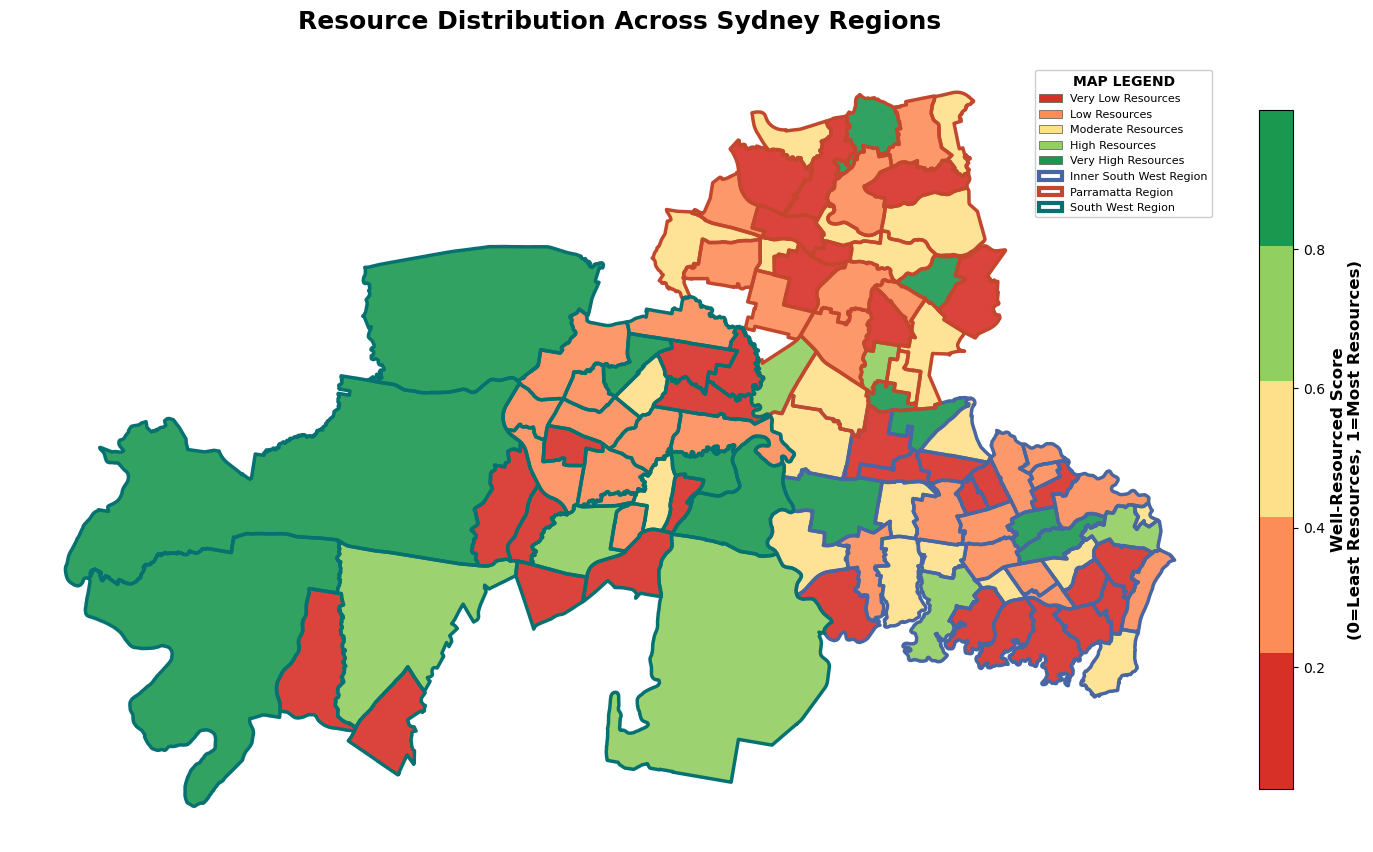

In [27]:
# 2. Visualizations

# Sydney Regions Resource Distribution Map with Comprehensive Legend
# Get geometry data for mapping
gdf = gpd.read_postgis("""
    SELECT s.sa2_code, s.sa2_name, s.sa4_name, s.final_score, sr.geom
    FROM well_resourced_scores s
    JOIN sa2_regions sr ON s.sa2_code = sr."SA2_CODE21"
""", conn, geom_col='geom')

# Convert to standard CRS for mapping
gdf = gdf.set_crs(epsg=4283)
gdf = gdf.to_crs(epsg=3857)  # Web Mercator projection for better visualization

# Create resource level classifications
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Create categories using quantiles for more intuitive interpretation
gdf['resource_category'] = pd.qcut(gdf['final_score'], 5, labels=[
    'Very Low Resources', 'Low Resources', 'Moderate Resources', 
    'High Resources', 'Very High Resources'
])

# Define vibrant color palette using a standard colorbrewer scheme (RdYlGn)
colors = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']
cmap = LinearSegmentedColormap.from_list('vibrant_resources', colors, N=5)

# Create enhanced map with a white background for clarity
fig, ax = plt.subplots(figsize=(15, 10), facecolor='white')
ax.set_facecolor('white')

# Define bold, distinctive styles for each SA4 region
sa4_styles = {
    'Sydney - Inner South West': {'edgecolor': '#4866a1', 'linewidth': 2.5, 'alpha': 0.9},  # Deep blue
    'Sydney - Parramatta': {'edgecolor': '#c3472d', 'linewidth': 2.5, 'alpha': 0.9},        # Red
    'Sydney - South West': {'edgecolor': '#067171', 'linewidth': 2.5, 'alpha': 0.9}          # Teal
}

# Plot each SA4 region with distinct styling
for sa4_name, style in sa4_styles.items():
    subset = gdf[gdf['sa4_name'] == sa4_name]
    subset.plot(
        column='final_score', 
        cmap=cmap,
        ax=ax,
        edgecolor=style['edgecolor'],
        linewidth=0.5,
        alpha=0.9
    )
    
    # Add SA4 region boundaries with thicker outlines to clearly distinguish each region
    subset.boundary.plot(
        ax=ax,
        color=style['edgecolor'],
        linewidth=style['linewidth'],
        alpha=1.0
    )

# Add colorbar legend with enhanced styling
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(
    gdf['final_score'].min(), gdf['final_score'].max()
))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.7, pad=0.02)
cbar.set_label("Well-Resourced Score\n(0=Least Resources, 1=Most Resources)", size=12, fontweight='bold')
cbar.ax.tick_params(labelsize=10)

# Create a figure-wide legend at the top with comprehensive explanations
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Create comprehensive legend elements
legend_title = "MAP LEGEND"

# Resource level legend items with explanations
resource_elements = [
    mpatches.Patch(facecolor=colors[0], edgecolor='#555555', linewidth=0.5, 
                   label='Very Low Resources'),
    mpatches.Patch(facecolor=colors[1], edgecolor='#555555', linewidth=0.5, 
                   label='Low Resources'),
    mpatches.Patch(facecolor=colors[2], edgecolor='#555555', linewidth=0.5, 
                   label='Moderate Resources'),
    mpatches.Patch(facecolor=colors[3], edgecolor='#555555', linewidth=0.5, 
                   label='High Resources'),
    mpatches.Patch(facecolor=colors[4], edgecolor='#555555', linewidth=0.5, 
                   label='Very High Resources')
]

# Region boundary legend items with explanations
region_elements = [
    mpatches.Patch(edgecolor=sa4_styles['Sydney - Inner South West']['edgecolor'], 
                   facecolor='white', linewidth=3.0, 
                   label='Inner South West Region'),
    mpatches.Patch(edgecolor=sa4_styles['Sydney - Parramatta']['edgecolor'], 
                   facecolor='white', linewidth=3.0, 
                   label='Parramatta Region'),
    mpatches.Patch(edgecolor=sa4_styles['Sydney - South West']['edgecolor'], 
                   facecolor='white', linewidth=3.0, 
                   label='South West Region')
]

# Explanation note for score calculation
explanation_text = "NOTE: Well-Resourced Score is derived from a composite of manufacturing businesses, \ntransport stops, schools, and points of interest, normalized and transformed to a 0-1 scale."

# Place legend in the upper right corner without interfering with the map
legend = ax.legend(
    handles=resource_elements + region_elements,
    loc='upper right',
    title=legend_title,
    framealpha=0.95,
    fontsize=8,
    title_fontsize=10,
    bbox_to_anchor=(0.99, 0.99),
    borderaxespad=0.5
)

# Make the legend title bold
legend.get_title().set_fontweight('bold')



# Add main title
plt.title('Resource Distribution Across Sydney Regions', fontsize=18, fontweight='bold', pad=20)

plt.axis('off')
plt.tight_layout()
plt.show()

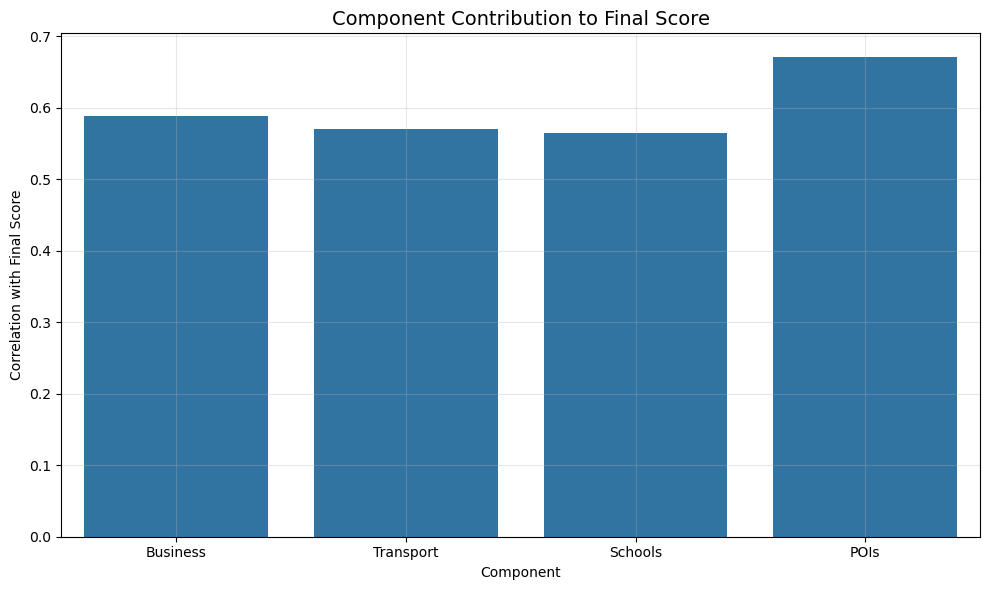

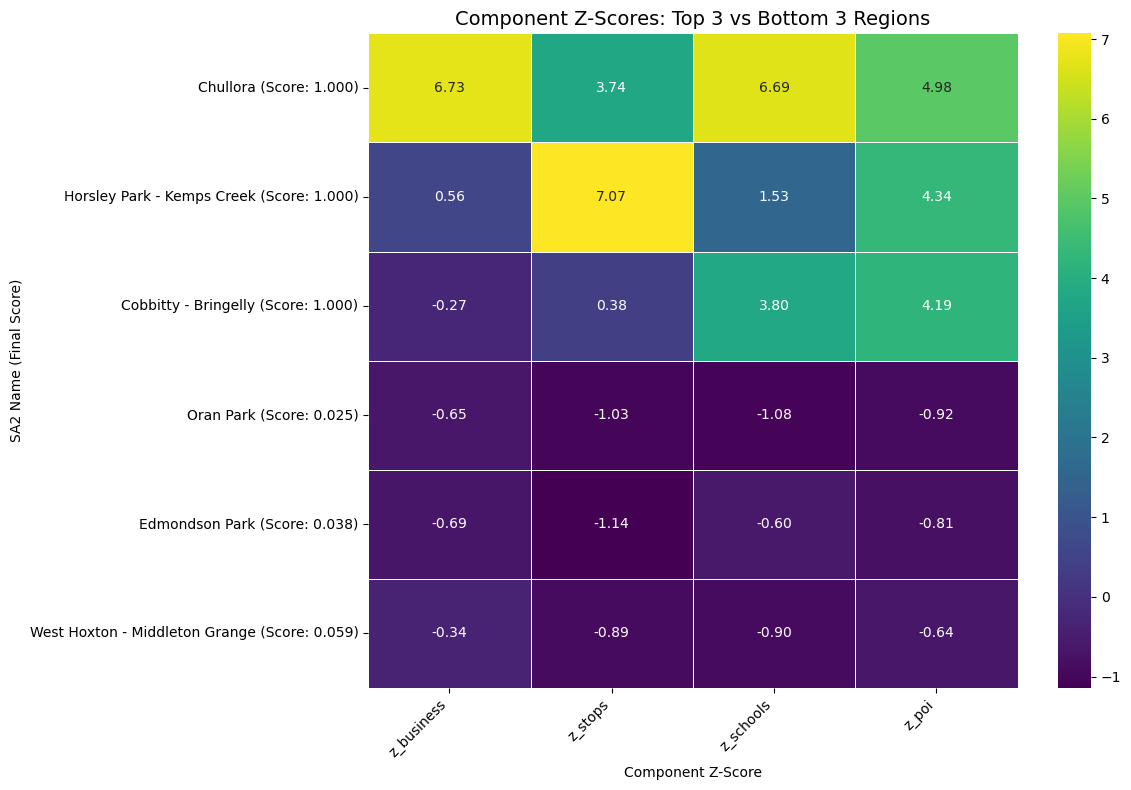

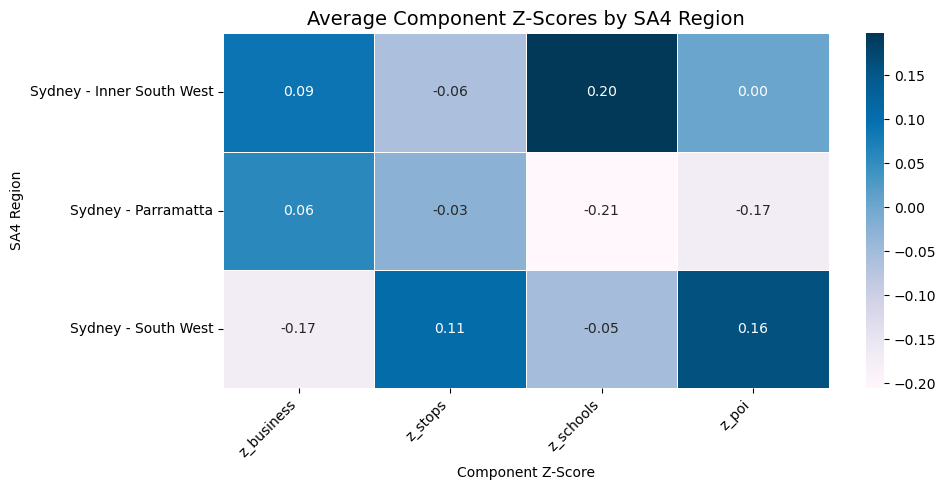

In [55]:
# 3. Component contribution analysis

# First, query the data including all z-scores from the well_resourced_scores table
scores_df = query(conn, """
    SELECT 
        sa2_code, 
        sa2_name,
        sa4_name,
        final_score,
        z_business,
        z_stops,
        z_schools,
        z_poi
    FROM 
        well_resourced_scores
""")

# Now use this dataframe for the analysis
plt.figure(figsize=(10, 6))
component_cols = ['z_business', 'z_stops', 'z_schools', 'z_poi']
corr_values = [scores_df['final_score'].corr(scores_df[col]) for col in component_cols]

sns.barplot(x=['Business', 'Transport', 'Schools', 'POIs'], y=corr_values)
plt.title('Component Contribution to Final Score', fontsize=14)
plt.xlabel('Component')
plt.ylabel('Correlation with Final Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create component heatmap for top/bottom regions with final_score in y-axis labels

# Select top 3 and bottom 3 SA2s
top3_df = scores_df.sort_values('final_score', ascending=False).head(3)
bottom3_df = scores_df.sort_values('final_score').head(3)
selected_sa2s_df = pd.concat([top3_df, bottom3_df])

# Prepare data for heatmap (only Z-scores)
heatmap_data = selected_sa2s_df.set_index('sa2_name')[component_cols]

# Create new y-axis labels that include the final_score
# Ensure 'sa2_name' and 'final_score' columns exist and are correctly named in selected_sa2s_df
new_yticklabels = [f"{row['sa2_name']} (Score: {row['final_score']:.3f})" 
                   for index, row in selected_sa2s_df.iterrows()]

plt.figure(figsize=(12, 8)) # Adjusted figsize for potentially longer y-labels
sns.heatmap(heatmap_data, cmap="viridis", annot=True, fmt=".2f", linewidths=.5, yticklabels=new_yticklabels)
plt.title('Component Z-Scores: Top 3 vs Bottom 3 Regions', fontsize=14)
plt.ylabel('SA2 Name (Final Score)') # Updated y-axis label
plt.xlabel('Component Z-Score')
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout()
plt.show()


# Calculate average Z-scores for each component per SA4 region
sa4_avg_zscores = scores_df.groupby('sa4_name')[component_cols].mean()

# Create the heatmap for SA4 average component Z-scores
plt.figure(figsize=(10, 5)) # Adjust figsize as needed
sns.heatmap(sa4_avg_zscores, cmap="PuBu", annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Component Z-Scores by SA4 Region', fontsize=14)
plt.ylabel('SA4 Region')
plt.xlabel('Component Z-Score')
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

,SA4 Region,Sample Size,Pearson Correlation,Pearson P-Value,Significant (p<0.05)
0,Sydney - Inner South West,41,0.2507,0.1139,No
1,Sydney - Parramatta,31,-0.0709,0.7045,No
2,Sydney - South West,32,0.1131,0.5375,No


Overall correlation across all regions: r = 0.1017, p = 0.3042


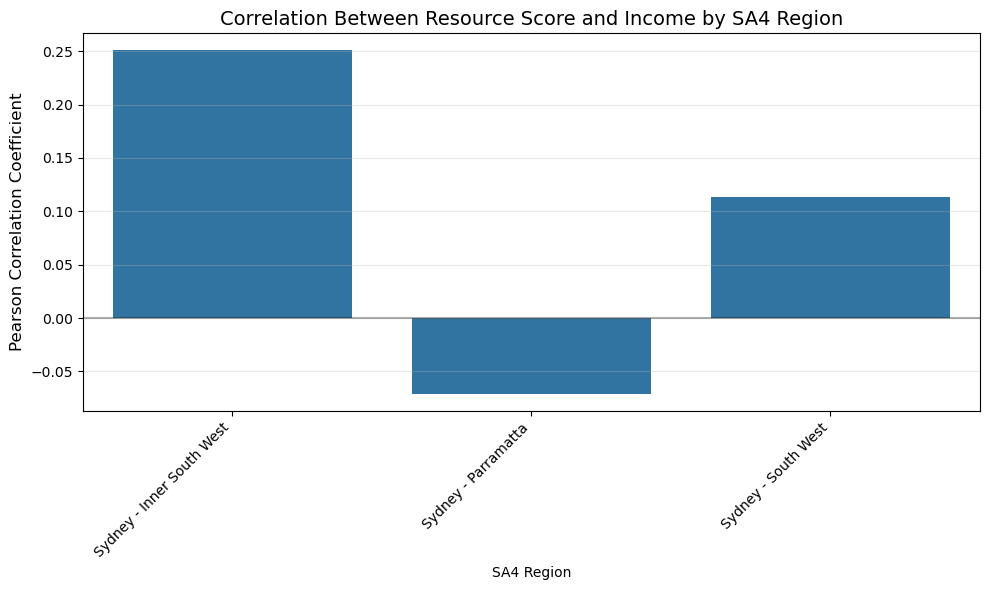

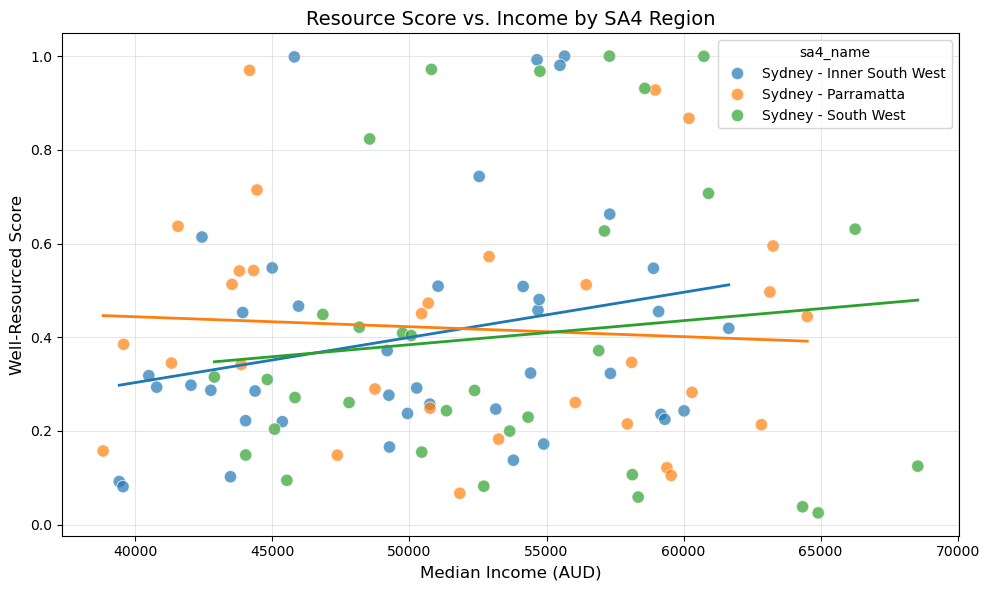

In [35]:
# Convert median_income to numeric to ensure proper calculations
income_analysis['median_income'] = pd.to_numeric(income_analysis['median_income'], errors='coerce')

# Create a results DataFrame to store correlation statistics by SA4 region
correlation_results = []

# Group by SA4 region and calculate correlation and p-value for each
for sa4_name, group in income_analysis.groupby('sa4_name'):
    if len(group) >= 5:  # Ensure enough data points for meaningful correlation
        # Calculate Pearson correlation and p-value
        correlation, p_value = stats.pearsonr(group['final_score'], group['median_income'])
        
        # Calculate Spearman rank correlation (more robust to outliers)
        spearman_corr, spearman_p = stats.spearmanr(group['final_score'], group['median_income'])
        
        # Add results to our collection
        correlation_results.append({
            'SA4 Region': sa4_name,
            'Sample Size': len(group),
            'Pearson Correlation': correlation,
            'Pearson P-Value': p_value,
            'Significant (p<0.05)': 'Yes' if p_value < 0.05 else 'No'
        })

# Create DataFrame from results
results_df = pd.DataFrame(correlation_results)

# Display the results with formatted numbers
pd.set_option('display.float_format', '{:.4f}'.format)
display(results_df)

# Calculate overall correlation for comparison
overall_corr, overall_p = stats.pearsonr(income_analysis['final_score'], income_analysis['median_income'])
print(f"Overall correlation across all regions: r = {overall_corr:.4f}, p = {overall_p:.4f}")

# Create visualization for the bar chart (correlation coefficients by region)
plt.figure(figsize=(10, 6))
sns.barplot(x='SA4 Region', y='Pearson Correlation', data=results_df)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.title('Correlation Between Resource Score and Income by SA4 Region', fontsize=14)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
# Fix the warning by using plt.setp
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Create a separate figure for the scatter plot (resource score vs income)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=income_analysis, x='median_income', y='final_score', 
                hue='sa4_name', alpha=0.7, s=80)

# Add regression lines for each region WITHOUT confidence intervals
for sa4_name, group in income_analysis.groupby('sa4_name'):
    sns.regplot(x='median_income', y='final_score', data=group,
                scatter=False, line_kws={'linewidth': 2}, ci=None)

plt.title('Resource Score vs. Income by SA4 Region', fontsize=14)
plt.xlabel('Median Income (AUD)', fontsize=12)
plt.ylabel('Well-Resourced Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.show()